In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
df = pd.read_csv('electric_vehicle_analytics.csv')

# Display basic information

In [ ]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (3000, 25)

First 5 rows:
   Vehicle_ID     Make          Model  Year         Region Vehicle_Type  \
0           1   Nissan           Leaf  2021           Asia          SUV   
1           2   Nissan           Leaf  2020      Australia        Sedan   
2           3  Hyundai  Kona Electric  2021  North America          SUV   
3           4     Audi      Q4 e-tron  2022         Europe    Hatchback   
4           5    Tesla        Model 3  2022      Australia        Truck   

   Battery_Capacity_kWh  Battery_Health_%  Range_km  Charging_Power_kW  ...  \
0                 101.7              75.5       565              153.6  ...   
1                  30.1              99.8       157              157.2  ...   
2                 118.5              84.0       677              173.6  ...   
3                  33.1              97.3       149              169.3  ...   
4                  81.3              85.6       481              212.8  ...   

   Max_Speed_kmh  Acceleration_0_

# Handle categorical variables

In [ ]:
le = LabelEncoder()
categorical_cols = ['Make', 'Model', 'Region', 'Vehicle_Type', 'Usage_Type']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


#Heatman Correlation Heat Map

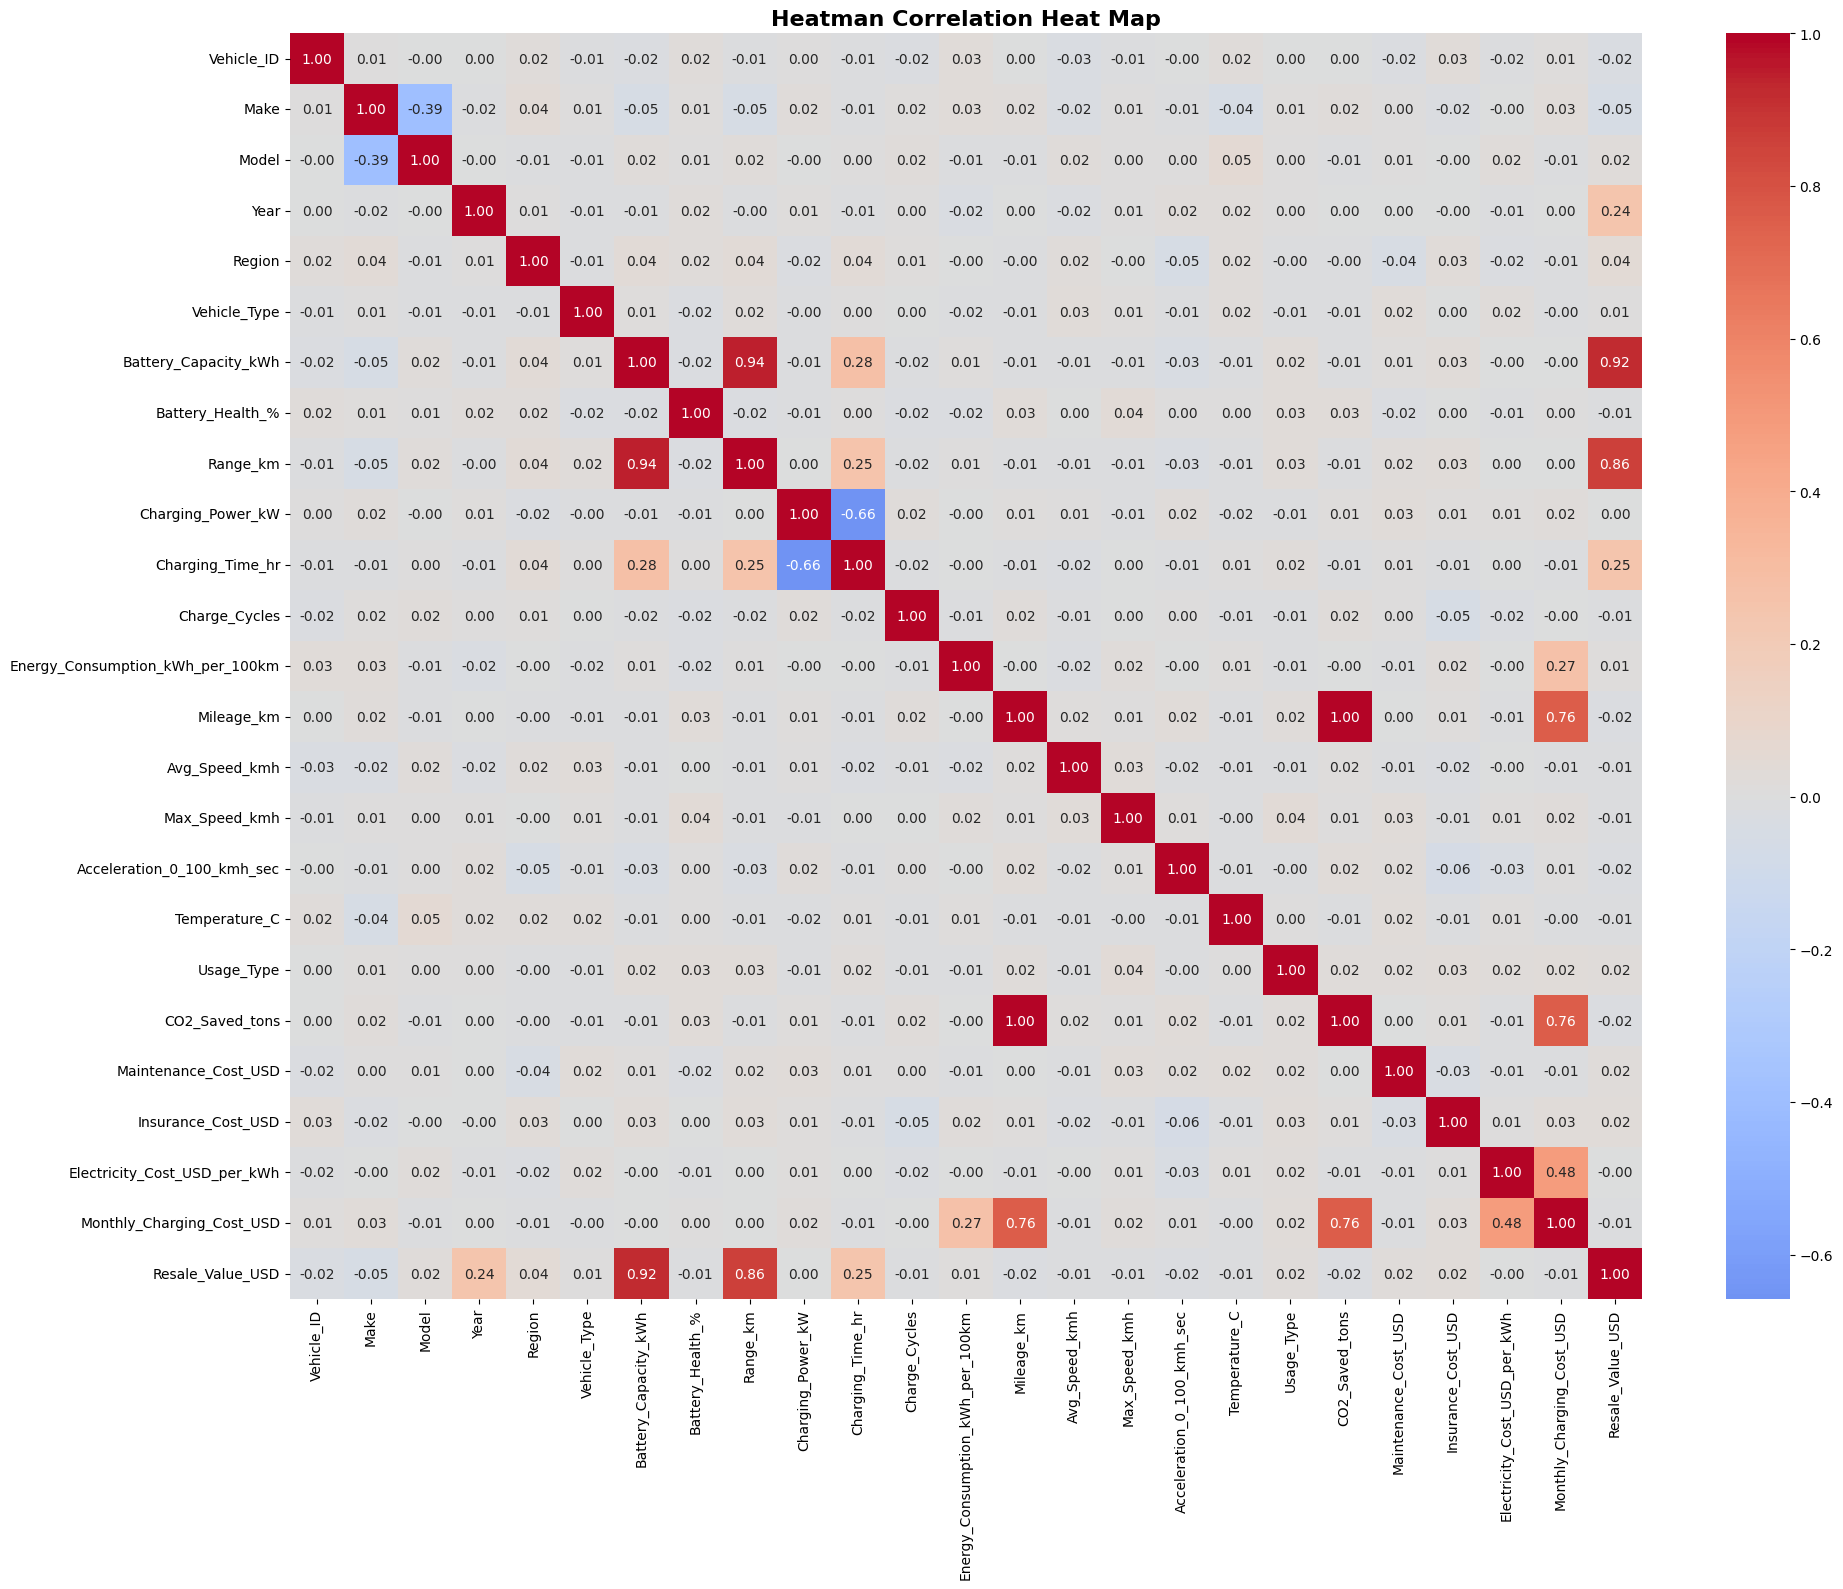

In [ ]:
plt.figure(figsize=(20, 16))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatman Correlation Heat Map', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#Box Plots for numerical features

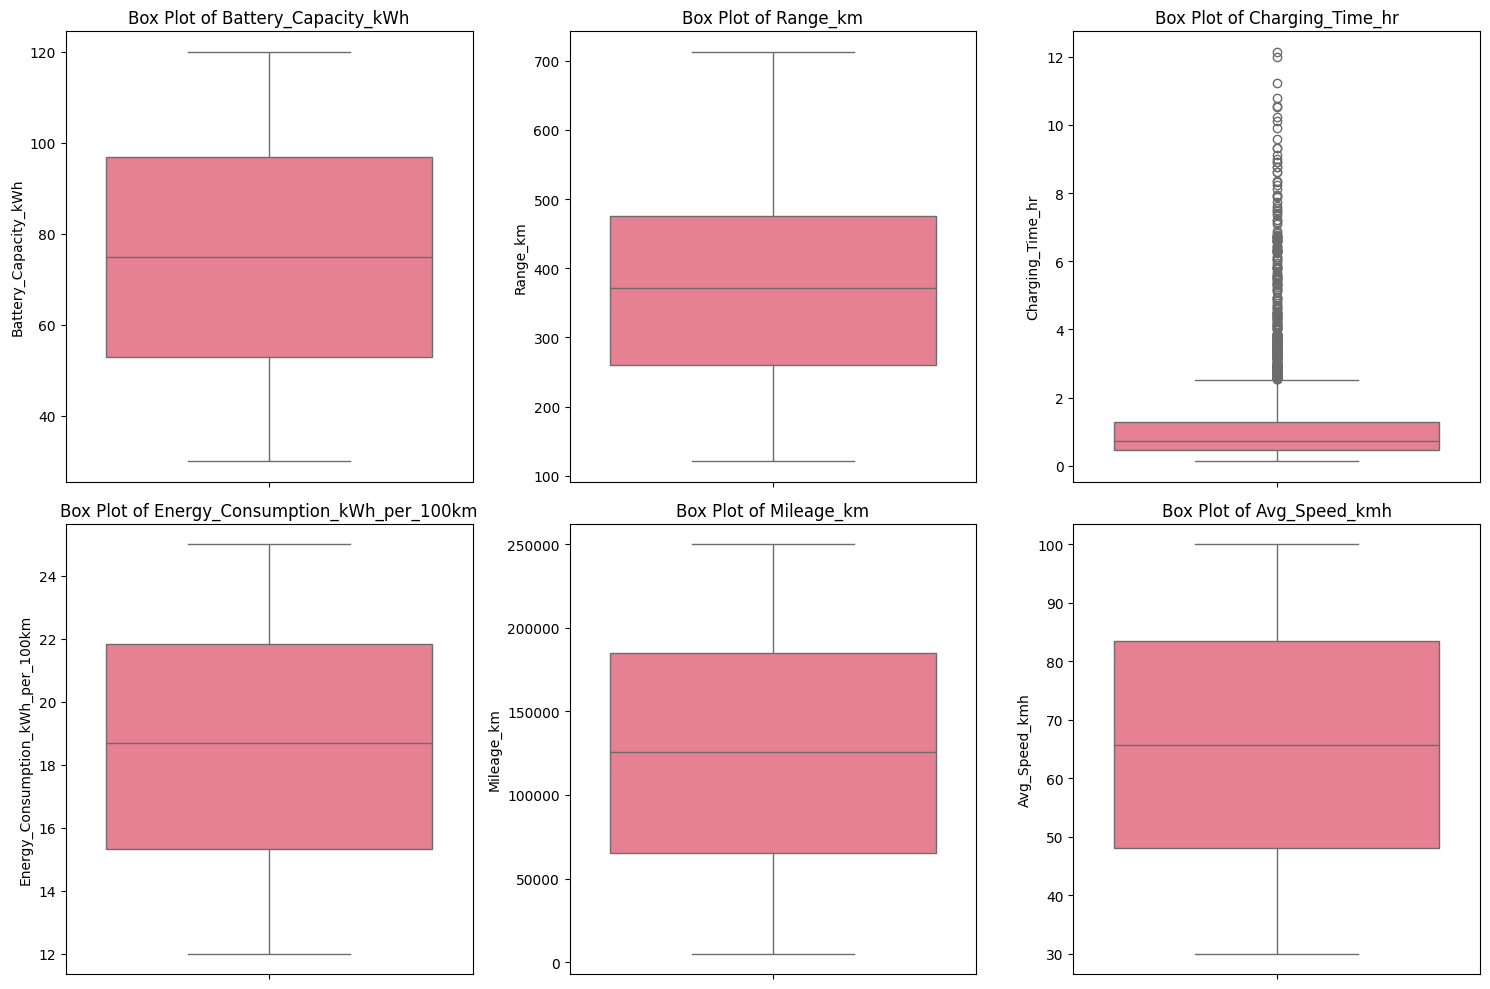

In [ ]:
numerical_features = ['Battery_Capacity_kWh', 'Range_km', 'Charging_Time_hr',
                     'Energy_Consumption_kWh_per_100km', 'Mileage_km', 'Avg_Speed_kmh']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

#Histograms for distribution analysis

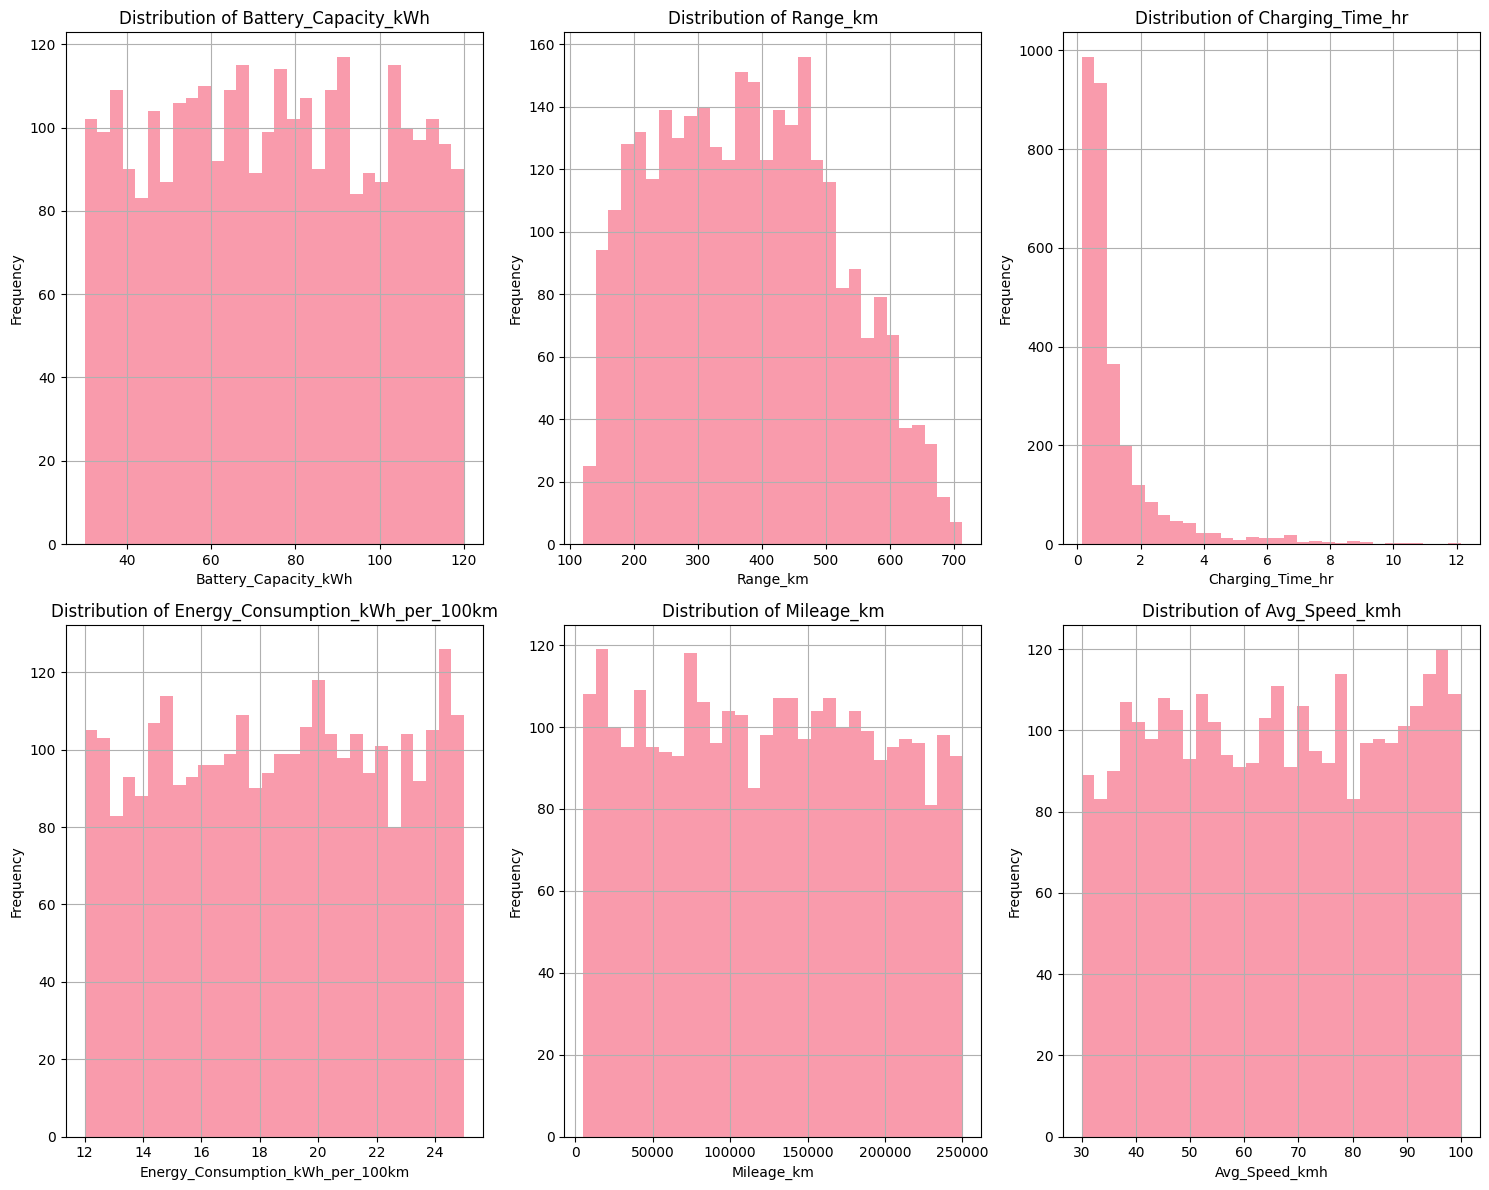

In [ ]:
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    df[feature].hist(bins=30, alpha=0.7)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(['Vehicle_ID', 'Resale_Value_USD'], axis=1)
y = df['Resale_Value_USD']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

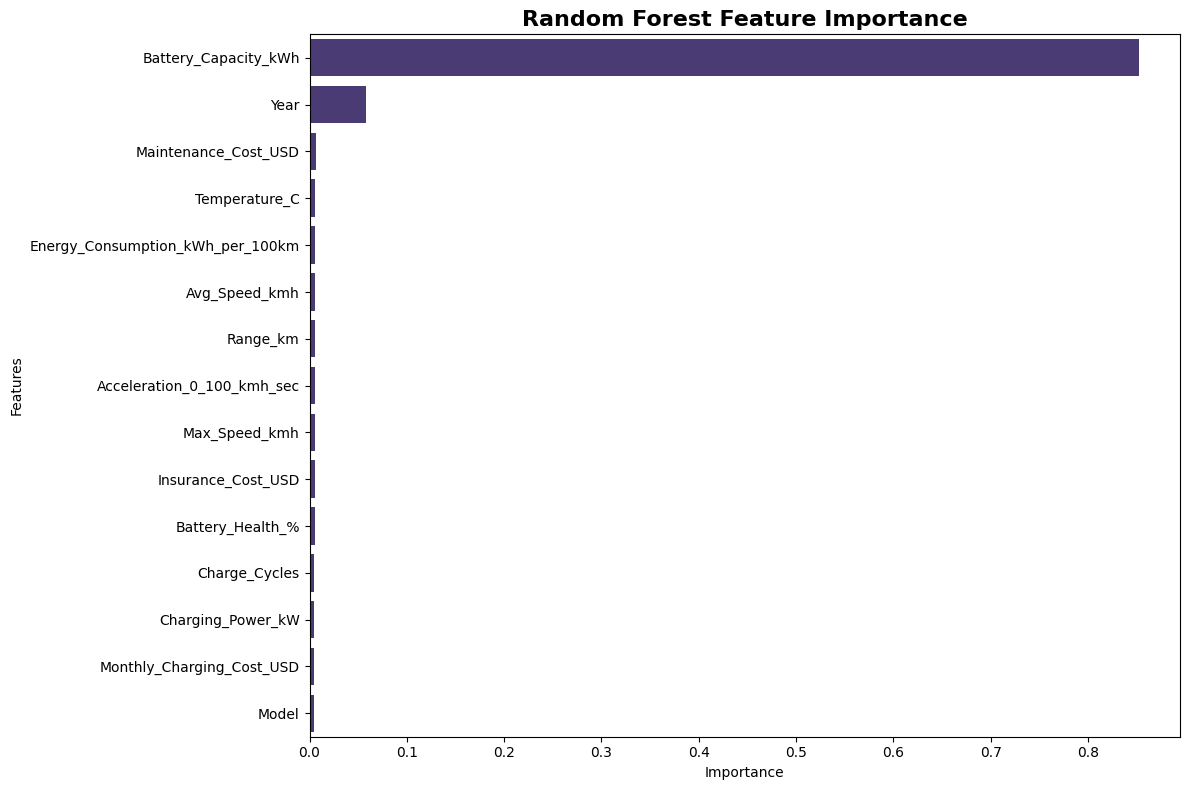

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Random Forest Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
y_class = (y > y.median()).astype(int)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [ ]:
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)


In [ ]:
from xgboost import XGBRegressor, XGBClassifier

In [ ]:
lin_reg_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': np.abs(lin_reg.coef_)
    }).sort_values('importance', ascending=False).head(10)

sns.barplot(x='importance', y='feature', data=lin_reg_importance, ax=ax2)
ax2.set_title('Linear Regression Feature Importance (Top 10)')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.style.use('default')
sns.set_palette("viridis")

In [ ]:
plt.figure(figsize=(16, 10))

<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1000 with 0 Axes>

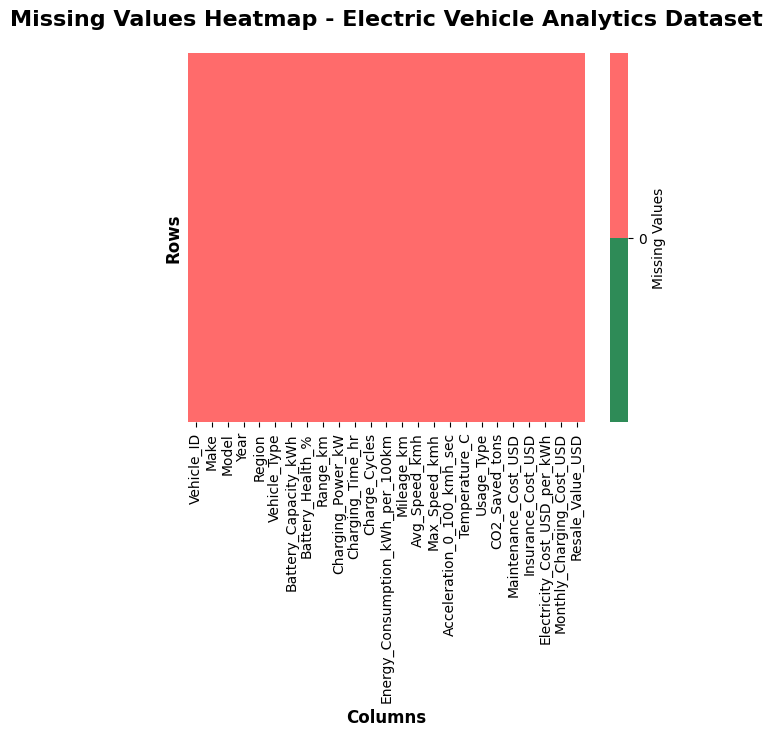

In [ ]:
missax = sns.heatmap(missing_matrix,
                 cbar=True,
                 cmap=['#2E8B57', '#FF6B6B'],
                 yticklabels=False,
                 cbar_kws={'label': 'Missing Values', 'ticks': [0, 1]})

plt.title('Missing Values Heatmap - Electric Vehicle Analytics Dataset',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Columns', fontsize=12, fontweight='bold')
plt.ylabel('Rows', fontsize=12, fontweight='bold')
ing_matrix = df.isnull()

In [ ]:
le = LabelEncoder()
categorical_cols = ['Make', 'Model', 'Region', 'Vehicle_Type', 'Usage_Type']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
median_resale = df['Resale_Value_USD'].median()
df['Resale_Class'] = (df['Resale_Value_USD'] > median_resale).astype(int)


In [ ]:
X = df.drop(['Vehicle_ID', 'Resale_Value_USD', 'Resale_Class'], axis=1)
y = df['Resale_Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("=" * 60)
print("F1 SCORE ANALYSIS - MULTIPLE MODELS")
print("=" * 60)

F1 SCORE ANALYSIS - MULTIPLE MODELS


In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

In [ ]:
f1_scores = {}
classification_reports = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)


Training Random Forest...

Training Logistic Regression...

Training SVM...

Training XGBoost...


In [ ]:
from sklearn.metrics import f1_score, classification_report

f1 = f1_score(y_test, y_pred)
f1_scores[name] = f1

report = classification_report(y_test, y_pred)
classification_reports[name] = report

print(f"{name} F1 Score: {f1:.4f}")
print(f"{name} Classification Report:\n{report}")

XGBoost F1 Score: 0.9097
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       300
           1       0.91      0.91      0.91       300

    accuracy                           0.91       600
   macro avg       0.91      0.91      0.91       600
weighted avg       0.91      0.91      0.91       600



In [ ]:
print("=" * 60)
print("CONTINGENCY TABLES ANALYSIS")
print("=" * 60)

CONTINGENCY TABLES ANALYSIS


In [ ]:
df['Resale_Value_Category'] = pd.cut(df['Resale_Value_USD'],
                                    bins=3,
                                    labels=['Low', 'Medium', 'High'])

df['Battery_Health_Category'] = pd.cut(df['Battery_Health_%'],
                                      bins=[0, 70, 85, 100],
                                      labels=['Poor', 'Good', 'Excellent'])

df['Mileage_Category'] = pd.cut(df['Mileage_km'],
                               bins=3,
                               labels=['Low', 'Medium', 'High'])

In [ ]:
print("\n1. VEHICLE TYPE vs RESALE VALUE CATEGORY")
print("-" * 40)

contingency_table1 = pd.crosstab(df['Vehicle_Type'], df['Resale_Value_Category'], margins=True)
print("Contingency Table:")
print(contingency_table1)
print("\n")


1. VEHICLE TYPE vs RESALE VALUE CATEGORY
----------------------------------------
Contingency Table:
Resale_Value_Category  Low  Medium  High   All
Vehicle_Type                                  
0                      180     399   194   773
1                      178     386   201   765
2                      166     370   202   738
3                      179     361   184   724
All                    703    1516   781  3000




In [ ]:
contingency_table1_percent = pd.crosstab(df['Vehicle_Type'], df['Resale_Value_Category'],
                                        normalize='index') * 100
print("Percentage Table (Row-wise):")
print(contingency_table1_percent.round(2))

Percentage Table (Row-wise):
Resale_Value_Category    Low  Medium   High
Vehicle_Type                               
0                      23.29   51.62  25.10
1                      23.27   50.46  26.27
2                      22.49   50.14  27.37
3                      24.72   49.86  25.41
